In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN
from tensorflow.keras.utils import to_categorical

In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_classifier = model.fit(
    X_train, y_train,
    epochs=50,  # You can adjust the number of epochs
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5408 - loss: 1.0869 - val_accuracy: 0.6041 - val_loss: 0.9558
Epoch 2/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5705 - loss: 0.9946 - val_accuracy: 0.6013 - val_loss: 0.9363
Epoch 3/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5722 - loss: 0.9823 - val_accuracy: 0.6027 - val_loss: 0.9392
Epoch 4/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5808 - loss: 0.9762 - val_accuracy: 0.6049 - val_loss: 0.9376
Epoch 5/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5856 - loss: 0.9716 - val_accuracy: 0.6049 - val_loss: 0.9235
Epoch 6/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5901 - loss: 0.9595 - val_accuracy: 0.6027 - val_loss: 0.9351
Epoch 7/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5924 - loss: 0.9628 - val_accuracy: 0.6041 - val_loss: 0.9301
Epoch 8/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5917 - loss: 0.9575 - val_accuracy: 0.

In [ ]:
# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {accuracy*100:.2f}%")

Test Accuracy: 59.61%


In [ ]:
import pandas as pd
# Load the dataset
data = pd.read_csv("/content/soil moisture dataset.zip")
print(data.head())

                        Time   Humidity  Atmospheric_Temp  Soil_Temp  \
0  2017-06-11 21:00:21+00:00  25.252367         15.487149  12.457884   
1  2017-06-11 22:00:21+00:00  33.304246         12.115891   8.514263   
2  2017-06-11 23:00:21+00:00  24.072051         17.319203  11.913326   
3  2017-06-12 00:00:21+00:00  45.026218         15.865805  14.700958   
4  2017-06-12 01:00:21+00:00  41.490917         13.842739   8.495549   

   Soil_Moisture  Dew_Point  
0      63.077305  23.918315  
1      40.097357  31.542544  
2     100.141916  21.142841  
3      64.638742  42.217799  
4      97.964697  38.257137  


In [ ]:
import zipfile
import os

zip_file_path = "/content/soil moisture dataset.zip"
extraction_path = "/content/"

# Check if the zip file exists before attempting to extract
if os.path.exists(zip_file_path):
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extraction_path)
    print(f"'{zip_file_path}' extracted to '{extraction_path}' successfully.")
    # List contents of the extracted directory to verify
    extracted_dir = os.path.join(extraction_path, 'soil moisture dataset')
    if os.path.exists(extracted_dir):
        print(f"Contents of '{extracted_dir}':")
        for item in os.listdir(extracted_dir):
            print(f"- {item}")
    else:
        print(f"Warning: Extracted directory '{extracted_dir}' not found.")
else:
    print(f"Error: Zip file not found at '{zip_file_path}'. Please upload it first.")

'/content/soil moisture dataset.zip' extracted to '/content/' successfully.
Contents of '/content/soil moisture dataset':
- soil_data_incl_rain_v3.csv


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# STEP 1: Make sure your dataset is loaded
# Use the original 'data' DataFrame that contains 'Soil_Moisture'

# STEP 2: Select correct columns (IMPORTANT)
# Replace column names with YOUR actual dataset columns
X = data[['Soil_Moisture', 'Atmospheric_Temp']]

# STEP 3: Convert to numeric (fix hidden errors)
X = X.apply(pd.to_numeric, errors='coerce')

# STEP 4: Remove missing values
X = X.dropna()

# STEP 5: Convert to numpy
X_values = X.to_numpy()

# STEP 6: Normalize
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_values)

# STEP 7: Sequence function
def create_sequences(data, look_back):
    X_seq = []
    y_seq = []

    for i in range(len(data) - look_back):
        X_seq.append(data[i:i+look_back])
        y_seq.append(data[i+look_back, 1])  # Atmospheric_Temp

    return np.array(X_seq), np.array(y_seq)

# STEP 8: Set window size
look_back = 10

# STEP 9: Create sequences
X_rnn, y_rnn = create_sequences(X_scaled, look_back)

# STEP 10: Check output
print("X_rnn shape:", X_rnn.shape)
print("y_rnn shape:", y_rnn.shape)

X_rnn shape: (8751, 10, 2)
y_rnn shape: (8751,)


In [ ]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_rnn, y_rnn, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (7000, 10, 2)
Shape of X_test: (1751, 10, 2)
Shape of y_train: (7000,)
Shape of y_test: (1751,)


In [ ]:
data.info()
print("Missing values:\n", data.isnull().sum())  # Check for missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8761 entries, 0 to 8760
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Time              8761 non-null   object 
 1   Humidity          8761 non-null   float64
 2   Atmospheric_Temp  8761 non-null   float64
 3   Soil_Temp         8761 non-null   float64
 4   Soil_Moisture     8761 non-null   float64
 5   Dew_Point         8761 non-null   float64
dtypes: float64(5), object(1)
memory usage: 410.8+ KB
Missing values:
 Time                0
Humidity            0
Atmospheric_Temp    0
Soil_Temp           0
Soil_Moisture       0
Dew_Point           0
dtype: int64


In [ ]:
# Re-split data into training and testing sets for the RNN regressor
# Use distinct variable names to avoid conflict with classification task's X_train, y_train
X_rnn_train, X_rnn_test, y_rnn_train, y_rnn_test = train_test_split(X_rnn, y_rnn, test_size=0.2, random_state=42)

regressor = Sequential()
regressor.add(SimpleRNN(units=50, return_sequences=True, input_shape=(X_rnn_train.shape[1], X_rnn_train.shape[2])))
regressor.add(SimpleRNN(units=50, return_sequences=True))
regressor.add(SimpleRNN(units=50, return_sequences=True))
regressor.add(SimpleRNN(units=50, return_sequences=False))
regressor.add(Dense(units=1))  # Output layer
regressor.summary()

# Compile the model
regressor.compile(optimizer='adam', loss='mean_squared_error')

NameError: name 'train_test_split' is not defined

In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_classifier = model.fit(
    X_train, y_train,
    epochs=50,  # You can adjust the number of epochs
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.3439 - loss: 1.2566 - val_accuracy: 0.3046 - val_loss: 1.1667
Epoch 2/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3361 - loss: 1.1700 - val_accuracy: 0.3602 - val_loss: 1.1100
Epoch 3/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3400 - loss: 1.1420 - val_accuracy: 0.3595 - val_loss: 1.1063
Epoch 4/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3373 - loss: 1.1292 - val_accuracy: 0.3680 - val_loss: 1.1089
Epoch 5/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3346 - loss: 1.1245 - val_accuracy: 0.3452 - val_loss: 1.0987
Epoch 6/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3389 - loss: 1.1187 - val_accuracy: 0.3702 - val_loss: 1.1032
Epoch 7/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3389 - loss: 1.1183 - val_accuracy: 0.3502 - val_loss: 1.1019
Epoch 8/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3400 - loss: 1.1089 - val_accuracy: 0.

In [ ]:
from tensorflow.keras.utils import to_categorical
X = df.drop(columns=['Target'])
y = df['Target']

# One-hot encoding
y = to_categorical(y)

In [ ]:
!ls -F /content/

 sample_data/  'soil moisture dataset'/  'soil moisture dataset.zip'


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
import pandas as pd
# Use quantiles (balanced classes)
# Reload df to ensure 'Soil_Moisture' column is present
df = pd.read_csv("/content/soil moisture dataset/soil_data_incl_rain_v3.csv")
df = df.drop(columns=['Time']) # Also drop 'Time' as done previously

df['Target'] = pd.qcut(df['Soil_Moisture'], q=3, labels=[0,1,2])
df = df.drop(columns=['Soil_Moisture'])

In [ ]:
print(df['Target'].value_counts())

Target
1    2921
0    2920
2    2920
Name: count, dtype: int64


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

model = Sequential()

model.add(Dense(256, activation='relu', input_shape=(X_train.shape[1],)))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))
model.add(Dense(3, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


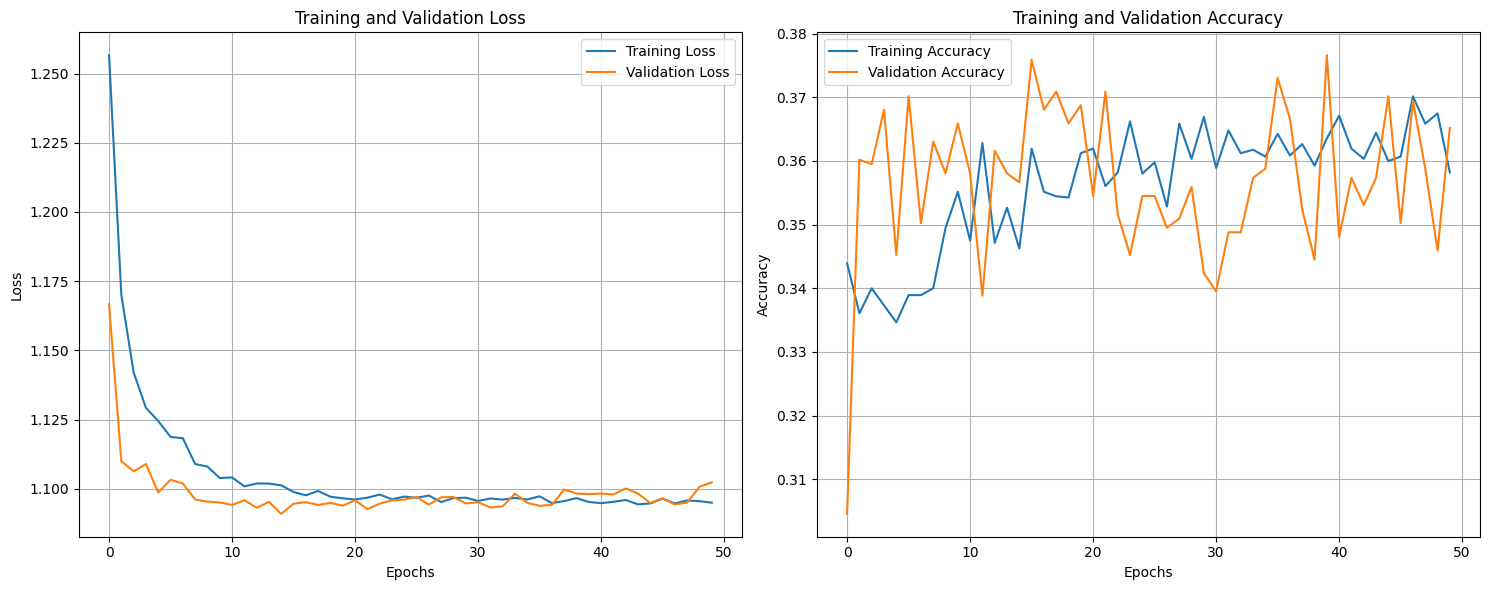

In [ ]:
plt.figure(figsize=(15, 6))

# Plot Training and Validation Loss
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(history_classifier.history['loss'], label='Training Loss')
plt.plot(history_classifier.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

# Plot Training and Validation Accuracy
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(history_classifier.history['accuracy'], label='Training Accuracy')
plt.plot(history_classifier.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


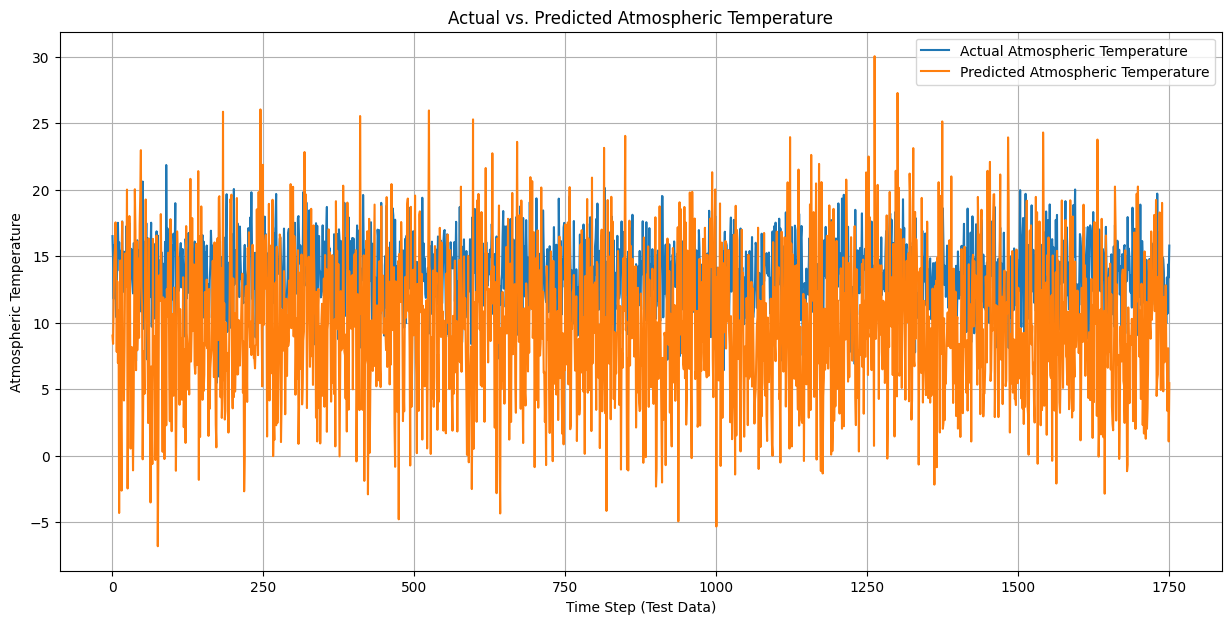

In [ ]:
# Make predictions on the test set

# Re-split X_rnn and y_rnn to get the correct X_test for the regressor model.
# This is necessary because X_test was overwritten by a later classification split.
_, X_rnn_test_for_regressor, _, y_rnn_test_for_regressor = train_test_split(X_rnn, y_rnn, test_size=0.2, random_state=42)

y_pred_scaled = regressor.predict(X_rnn_test_for_regressor)

# We need to inverse transform the predictions and actual values to their original scale.
# Remember that y_rnn (and thus y_rnn_test_for_regressor) was predicting Atmospheric_Temp (index 1).
# The scaler was fit on X.values (all features).
# So we need to create dummy arrays to inverse transform only the Atmospheric_Temp part.

# Create dummy array for inverse transformation of y_test (y_rnn_test_for_regressor)
dummy_y_test = np.zeros((len(y_rnn_test_for_regressor), X_scaled.shape[1]))
dummy_y_test[:, 1] = y_rnn_test_for_regressor.flatten()  # Atmospheric_Temp is at index 1
y_test_original = scaler.inverse_transform(dummy_y_test)[:, 1]

# Create dummy array for inverse transformation of predictions
dummy_y_pred = np.zeros((len(y_pred_scaled), X_scaled.shape[1]))
dummy_y_pred[:, 1] = y_pred_scaled.flatten()  # Atmospheric_Temp is at index 1
y_pred_original = scaler.inverse_transform(dummy_y_pred)[:, 1]

# Plot actual vs. predicted values
plt.figure(figsize=(15, 7))
plt.plot(y_test_original, label='Actual Atmospheric Temperature')
plt.plot(y_pred_original, label='Predicted Atmospheric Temperature')
plt.title('Actual vs. Predicted Atmospheric Temperature')
plt.xlabel('Time Step (Test Data)')
plt.ylabel('Atmospheric Temperature')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN
from tensorflow.keras.utils import to_categorical

In [ ]:
# Train the RNN regressor model
history_regressor = regressor.fit(
    X_rnn_train, y_rnn_train,
    epochs=50,  # You can adjust the number of epochs
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# After training, you can re-run cell `qotqnkrI4qzu` to see the updated 'Actual vs. Predicted Atmospheric Temperature' plot.